Implementar una aproximación del algoritmo descrito en el PDF proporcionado, utilizando para ello las parejas de imágenes de ejemplo suministradas.

In [3]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

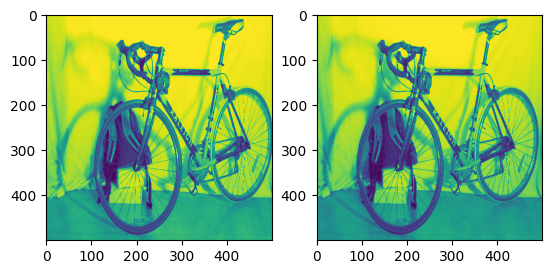

In [4]:
img1 = cv2.imread('images/im0.png',0)
img2 = cv2.imread('images/im1.png',0)
img1 = cv2.resize(img1, (500, 500))
img2 = cv2.resize(img2, (500, 500))
plt.subplot(121),plt.imshow(img1)
plt.subplot(122),plt.imshow(img2)
plt.show()

In [6]:
def new_image_like(img):
    """Crea un lienzo nuevo para guardar los valores de profundidad."""
    return np.zeros_like(img, dtype=np.float32) # reciclado de la práctica anterior

def get_feature_descriptor(img, i, j): # reciclado de la práctica anterior
    """Extrae una ventana de la imagen."""
    x1 = max(0, i - 2)
    x2 = min(img.shape[1], i + 3)

    y1 = max(0, j - 2)
    y2 = min(img.shape[0], j + 3)

    mask = img[y1:y2, x1:x2]
    return mask

def columns(img):
    return img.shape[-1]

def score_feature_match(f_ij, f_i2j):
    """Calcula la diferencia entre dos ventanas."""
    return math.dist(f_ij.ravel(), f_i2j.ravel())

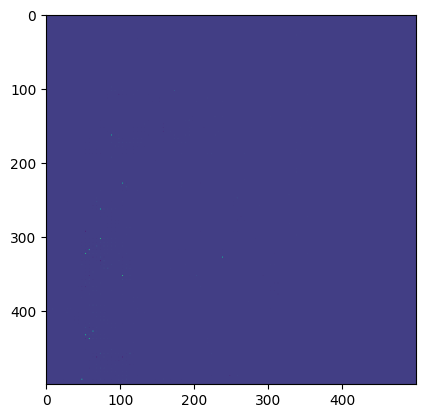

In [ ]:
def compute_depth(img1, img2, baseline, f, doffs):
    depth = new_image_like(img1)
    height, width = img1.shape
    _, width2 = img2.shape
    for i in range(3, width-2, 5):
        for j in range(3, height-2, 5):
            f_ij = get_feature_descriptor(img1, i, j)
            best_score = np.inf
            best_i = np.nan
            for i2 in range(3, width2-2):
                f_i2j = get_feature_descriptor(img2, i2, j)
                score = score_feature_match(f_ij, f_i2j)
                if score < best_score:
                    best_score = score
                    best_i = i2
            depth[j, i] = baseline * f / (i - best_i + doffs + EPSILON)
    return depth

f= 5299.313
width=2988
height=2008
doffs=174.186
baseline=177.288 #in mm
EPSILON = 0.000001
depth_img = compute_depth(img1, img2, baseline, f, doffs)
plt.imshow(depth_img)

La solución anterior solo pinta un pixel. 

Le pedimos a ChatGPT, que partiendo del otro código, pintara los píxeles de la ventana.

500


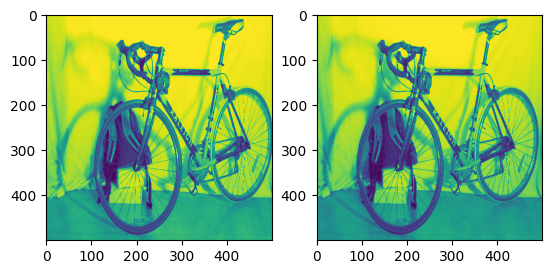

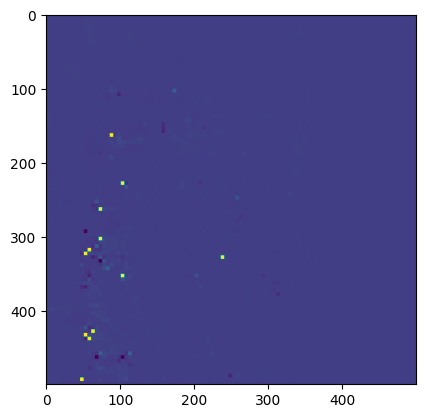

In [ ]:
def compute_depth(img1, img2, baseline, f, doffs):
    depth = new_image_like(img1)
    height, width = img1.shape
    _, width2 = img2.shape
    values = []

    for i in range(3, width-2, 5):      # columnas
        for j in range(3, height-2, 5): # filas
            # ventana centrada en (i, j)
            x1 = max(0, i - 2)
            x2 = min(img1.shape[1], i + 3)
            y1 = max(0, j - 2)
            y2 = min(img1.shape[0], j + 3)

            f_ij = img1[y1:y2, x1:x2]
            best_score = np.inf
            best_i = np.nan

            for i2 in range(3, width2-2):
                # misma fila j, misma ventana en x alrededor de i2
                x1_2 = max(0, i2 - 2)
                x2_2 = min(img2.shape[1], i2 + 3)
                f_i2j = img2[y1:y2, x1_2:x2_2]

                score = score_feature_match(f_ij, f_i2j)
                if score < best_score:
                    best_score = score
                    best_i = i2
            
            disparity = i - best_i
            depth_val = baseline * f / (disparity + doffs + EPSILON)
            # aquí se asigna el mismo valor a toda la ventana
            depth[y1:y2, x1:x2] = depth_val

    return depth

f= 5299.313
width=2988
height=2008
doffs=174.186
baseline=177.288 #in mm
ndisp=180
p = 1 # CAMBIAR
EPSILON = 0.000001
depth_img = compute_depth(img1, img2, baseline, f, doffs)
plt.imshow(depth_img)

500


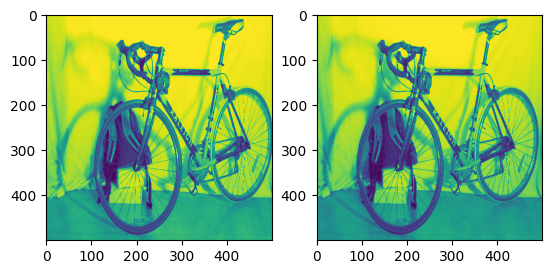

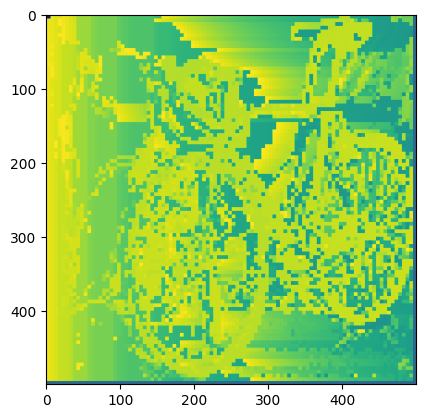

In [ ]:
# Copia de Seguridad
import cv2
from matplotlib import pyplot as plt

img1 = cv2.imread('images/im0.png',0)
img2 = cv2.imread('images/im1.png',0)
img1 = cv2.resize(img1, (500, 500))
img2 = cv2.resize(img2, (500, 500))
print(img1.shape[0])
plt.subplot(121),plt.imshow(img1)
plt.subplot(122),plt.imshow(img2)
plt.show()


def compute_depth(img1, img2, baseline, f, doffs):
    depth = new_image_like(img1)
    height, width = img1.shape
    _, width2 = img2.shape
    values = []

    for i in range(3, width-2, 5):
        for j in range(3, height-2, 5):
            # ventana centrada en (i, j)
            x1 = max(0, i - 2)
            x2 = min(img1.shape[1], i + 3)
            y1 = max(0, j - 2)
            y2 = min(img1.shape[0], j + 3)

            f_ij = img1[y1:y2, x1:x2]
            best_score = np.inf
            best_i = np.nan

            for i2 in range(3, width2-2):
                # misma fila j, misma ventana en x alrededor de i2
                x1_2 = max(0, i2 - 2)
                x2_2 = min(img2.shape[1], i2 + 3)
                f_i2j = img2[y1:y2, x1_2:x2_2]

                score = score_feature_match(f_ij, f_i2j)
                if score < best_score:
                    best_score = score
                    best_i = i2
            
            # Umbral comentado en clase
            disparity = i - best_i
            if disparity < -10 and len(values)!=0:
                disparity = max(values)
                values.append(disparity)
            else:
                values.append(disparity)

            depth_val = baseline * f / (disparity + doffs + EPSILON)
            # aquí se asigna el mismo valor a toda la ventana
            depth[y1:y2, x1:x2] = depth_val

    return depth

f= 5299.313
width=2988
height=2008
doffs=174.186
baseline=177.288 #in mm
EPSILON = 0.000001
depth_img = compute_depth(img1, img2, baseline, f, doffs)
plt.imshow(depth_img)